# Signal Processing Project

## Seismic Data Processing and Analysis

Work developed by:
- Carolina Dias (up202500534)
- Mariana Pereira (up202205093)
- Simão Bernardo (up202502529)
- Sofia Fernandes (up202502530)

<br>

----

## 0. Project Description


This project was developed within the scope of the Signal Processing course and focuses on the analysis of signals generated by seismic activity. The main objective is to analyze seismic waveform data by applying digital signal processing techniques to distinguish the signals captured by different sensor types (Broadband, Short-Period, and Accelerometer). This goal is achieved by developing a machine learning classification system capable of automatically discriminating between these sensor-specific patterns.

The dataset, obtained from the Southern California Earthquake Data Center (SCEDC - https://scedc.caltech.edu/), consists of raw seismic waveform recordings collected from selected seismic stations. These signals represent ground motion as a function of time and are accessed and processed using the ObsPy library. Each waveform corresponds to a specific seismic event recorded at a given station and is sampled at a fixed rate, enabling both time-domain and frequency-domain analyses.


In [ ]:
# Load libraries
#!pip install obspy numpy scipy matplotlib
from obspy.clients.fdsn import Client;
from obspy import UTCDateTime, Stream;
import pandas as pd;
import time;
import numpy as np;
import matplotlib.pyplot as plt;
from scipy.fft import rfft, rfftfreq;
from sklearn.ensemble import RandomForestClassifier;
from sklearn.model_selection import train_test_split;
from sklearn.metrics import classification_report, confusion_matrix;
import seaborn as sns;
from obspy.signal.filter import envelope;
from scipy.stats import linregress;
from scipy.stats import kurtosis;


## 1. Data Importing and Preprocessing

### 1.1. Initial Approach - single seismic event

Initially, data collection was based on one significant seismic event (the 2019-07-06 M7.1 Ridgecrest earthquake), with a target of 100 waveform samples per sensor type. However, this approach resulted in a highly imbalanced dataset, as short-period sensors (EHZ) are deployed at considerably fewer stations than broadband (HHZ) and accelerometer (HNZ) sensors. To mitigate this, we performed feature extraction and quality control on each downloaded waveform.

In [ ]:
''' import time
import pandas as pd
import numpy as np
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis

# Connect to SCEDC and define time window
client = Client("SCEDC")
t0 = UTCDateTime("2019-07-06T03:19:53")
duration = 60

# Define targets
targets = [{"code": "EHZ", "label": "Short_Period", "limit": 100},
    {"code": "HHZ", "label": "Broadband",    "limit": 100},
    {"code": "HNZ", "label": "Accelerometer","limit": 100}]

dataset = []

# Feature extraction function
def extract_features(trace, label):
    if trace.stats.sampling_rate != 100.0:
        try:
            trace.resample(100.0)
        except:
            return None # Skip if resample fails

    tr = trace.copy()
    tr.detrend("linear")
    tr.taper(0.05)

    data = tr.data
    if len(data) == 0 or np.max(np.abs(data)) == 0: return None
    data = data / np.max(np.abs(data)) # Normalize

    # Fast Fourier Transform and Power Spectral Density
    n = len(data)
    yf = np.abs(rfft(data))
    xf = rfftfreq(n, 1/100.0)
    psd = yf / np.sum(yf)

    feat = {'label': label, 'station': tr.stats.station}
    feat['spectral_centroid'] = np.sum(xf * psd)
    feat['energy_very_low_<1Hz'] = np.sum(psd[xf < 1.0])
    feat['energy_high_>20Hz'] = np.sum(psd[xf > 20.0])
    feat['kurtosis'] = kurtosis(data)
    return feat

print(f"Starting download for event: {t0}")

for target in targets:
    code = target['code']
    label = target['label']
    limit = target['limit']

    print(f"\n--- Processing {label} ({code}) ---")

    # 1. Get List of Stations
    try:
        inventory = client.get_stations(network="CI", station="*", channel=code,
                                        starttime=t0, endtime=t0+duration)
        stations = [sta.code for net in inventory for sta in net]
        print(f"Found {len(stations)} potential stations.")
    except Exception as e:
        print(f"Could not fetch station list: {e}")
        continue

    # 2. Download waveforms one by one
    count = 0
    for sta in stations:
        if count >= limit: break

        try:
            # Request ONE station
            st = client.get_waveforms("CI", sta, "*", code, t0, t0+duration)
            tr = st[0]

            # Quality control
            if tr.stats.npts < (duration * 100 * 0.8): continue

            feat = extract_features(tr, label)
            if feat:
                dataset.append(feat)
                count += 1
                # print(f"  Got {sta}") # Uncomment to see progress

            time.sleep(0.1)

        except Exception:
            pass # Station might be offline, skip it

    print(f"Successfully collected {count} samples for {label}.")

# Create DataFrame
df = pd.DataFrame(dataset)
print("\nFinal Dataset Summary:")
print(df.groupby('label').size()) '''

### 1.2. Improved Approach - multiple seismic events

To address data imbalance, we collected waveforms from 4 major Southern California earthquakes:

  - 2019-07-06 M7.1 (Ridgecrest)

  - 2019-07-04 M6.4 (Ridgecrest)

  - 2020-06-24 M5.8 (Lone Pine)

  - 2014-03-29 M5.1 (La Habra)

Firstly, the `obspy` and `pandas` libraries were imported. The `client` module is used to connect to the SCEDC FDSN database, whereas the `UTCDateTime` is used to define specific time windows for querying seismic stations.
To understand the variety and distribution of seismic instruments in the Southern California network, we queried the SCEDC inventory to identify all vertical-component sensors (`*Z`) operating during our target time period. We set `level="channel"` in order to retrieve information regarding each sensor (e.g., sampling rate, instrument features). This information is then grouped by a for loop and converted to a data frame (`df_sensors`), which is then summarised.
The summary revealed 14 distinct sensor channel types with varying sampling rates:

  - High-sample-rate sensors (100-200 Hz): **HHZ** (253 stations), **HNZ** (354 (100 Hz) + 255 (200 Hz) stations), **EHZ** (86 stations)

  - Medium-sample-rate sensors (40 Hz): **BHZ** (253 stations), **BNZ** (6 stations)

  - Low-sample-rate sensors (1 Hz): **LHZ** (253 stations), **LNZ** (356 stations)

  - Very-low-sample-rate sensors (0.1 Hz): **VHZ** (253 stations)

From the 14 sensor channel types identified in the network, the **high-sample-rate** sensors (HNZ, HHZ, and EHZ) were selected for our detailed analysis, since high sampling rates support more precise signal representation and enables more accurate time- and frequency-domain analyses.

In [ ]:
client = Client("SCEDC")

# List of events
events = [
    UTCDateTime("2019-07-06T03:19:53"),
    UTCDateTime("2019-07-04T17:33:49"),
    UTCDateTime("2020-06-24T17:58:35"),
    UTCDateTime("2014-03-29T04:09:42")
]

# Fetch inventory for vertical channels
inventory = client.get_stations(network="CI", station="*", location="*",
                                channel="*Z", starttime=events[0], endtime=events[0]+60,
                                level="channel")

sensor_types = [
    {"Station": sta.code, "Channel": chan.code,
     "Sampling_Rate": chan.sample_rate,
     "Description": chan.sensor.description if chan.sensor else "Unknown"}
    for net in inventory for sta in net for chan in sta
]

df_sensors = pd.DataFrame(sensor_types)
summary = df_sensors.groupby(['Channel','Sampling_Rate']).size().reset_index(name='Count')
print(summary)

### 1.3. Handling Data Imbalance

To address data imbalance, we implemented a balanced sampling strategy - 50 samples per event for each of the 3 sensor types. This step resulted in a balanced dataset of 600 traces (4 events × 3 sensor types × 50 samples).

In [ ]:
duration = 60
targets = [{"code": "EHZ", "label": "Short_Period", "limit_per_event": 50},
    {"code": "HHZ", "label": "Broadband",    "limit_per_event": 50},
    {"code": "HNZ", "label": "Accelerometer","limit_per_event": 50}]

all_waveforms = Stream()

print(f"--- Step 1: Building Massive Dataset ({len(events)} Events) ---")

for event_time in events:
    for target in targets:
        code, label, limit = target['code'], target['label'], target['limit_per_event']
        try:
            # 1. Get stations active for THIS specific event
            inventory = client.get_stations(network="CI", station="*", channel=code,
                                            starttime=event_time, endtime=event_time+duration)
            stations = [sta.code for net in inventory for sta in net]
            np.random.shuffle(stations)
        except Exception:
            continue

        count = 0
        for sta in stations:
            if count >= limit: break
            try:
                # 2. Download trace
                st = client.get_waveforms("CI", sta, "*", code, event_time, event_time+duration)
                tr = st[0]

                # 3. Quality Control (Skip flatlines or broken data)
                if np.max(np.abs(tr.data)) == 0: continue

                # 4. Processing
                tr.detrend("linear")
                tr.taper(0.05)

                # Tag and store
                tr.stats.sensor_label = label
                all_waveforms.append(tr)
                count += 1
                time.sleep(0.05)
            except Exception:
                continue
        print(f"Collected {count} {label} traces for event {event_time.date}")

print(f"Total traces collected: {len(all_waveforms)}")


--- Step 1: Building Massive Dataset (4 Events) ---
Collected 50 Short_Period traces for event 2019-07-06
Collected 50 Broadband traces for event 2019-07-06
Collected 50 Accelerometer traces for event 2019-07-06
Collected 35 Short_Period traces for event 2019-07-04
Collected 50 Broadband traces for event 2019-07-04
Collected 50 Accelerometer traces for event 2019-07-04
Collected 50 Short_Period traces for event 2020-06-24
Collected 50 Broadband traces for event 2020-06-24
Collected 50 Accelerometer traces for event 2020-06-24
Collected 50 Short_Period traces for event 2014-03-29
Collected 50 Broadband traces for event 2014-03-29
Collected 50 Accelerometer traces for event 2014-03-29
Total traces collected: 585


## 2. Visualization and Feature Extraction

After building a balanced dataset of seismic waveforms, we proceeded with visual inspection and feature extraction to better understand the data characteristics and prepare it for subsequent analysis.


### 2.1. Visualization - time-domain

In order to evaluate how the waveform evolve over time, a time-domain plot was computed. Initially, the sample was obtained by selecting the **first available trace** of each sensor. The traces were then **normalized** by the maximum absolute amplitude.

The resulting plot is represented below, showing normalized seismograms for Broadband (HHZ), Short-Period (EHZ), and Accelerometer (HNZ):

- **Broadband** (HHZ, blue): Smooth, **low-amplitude** oscillations; the energy gradually increases near the main shaking period (50–60 s). This reflects the broadband sensor’s sensitivity to low-frequency, long-period seismic waves.

- **Short-Period** (EHZ, orange): **Sharp peaks** and rapid oscillations; amplitude spikes occur during the main shaking, showing the sensor’s responsiveness to higher-frequency components.

- **Accelerometer** (HNZ, green): Combines **medium-amplitude** oscillations with some high-frequency peaks; characteristic of accelerometers, which capture both moderate-frequency motion and strong shaking events.

The normalization allows direct visual comparison, highlighting differences in waveform smoothness, amplitude distribution, and impulsiveness across sensor types.

### 2.2. Visualization - frequency-domain

Then, we computed a frequency-domain plot, in order to inspect the **spectral content** of each sensor, determining where energy is concentrated and how the sensor types differ. Computing a frequency-domain plot first required calculating the **Fast Fourier Transform (FFT)**. The plot represented amplitude vs. frequency (0.1-50 Hz) on a log-log scale.

The frequency-domain plot shows the log-log spectral amplitude of the same traces:

- **Broadband** (HHZ, blue): Dominant spectral energy is concentrated below 1–2 Hz, confirming its low-frequency response. The amplitude drops sharply above ~10 Hz.

- **Short-Period** (EHZ, orange): Spectral energy spreads across a wider range, peaking in the 2–10 Hz band. Energy decreases gradually at higher frequencies, consistent with the impulsive behavior seen in the time domain.

- **Accelerometer** (HNZ, green): Energy is more evenly distributed across mid- to high-frequency bands (5–30 Hz), indicating strong high-frequency sensitivity suitable for capturing ground motion spikes.

The spectral content aligns with sensor design: broadband sensors capture long-period waves, short-period sensors capture moderate-to-high frequencies, and accelerometers detect strong, high-frequency motion.


--- Step 2: Visualizing Samples ---


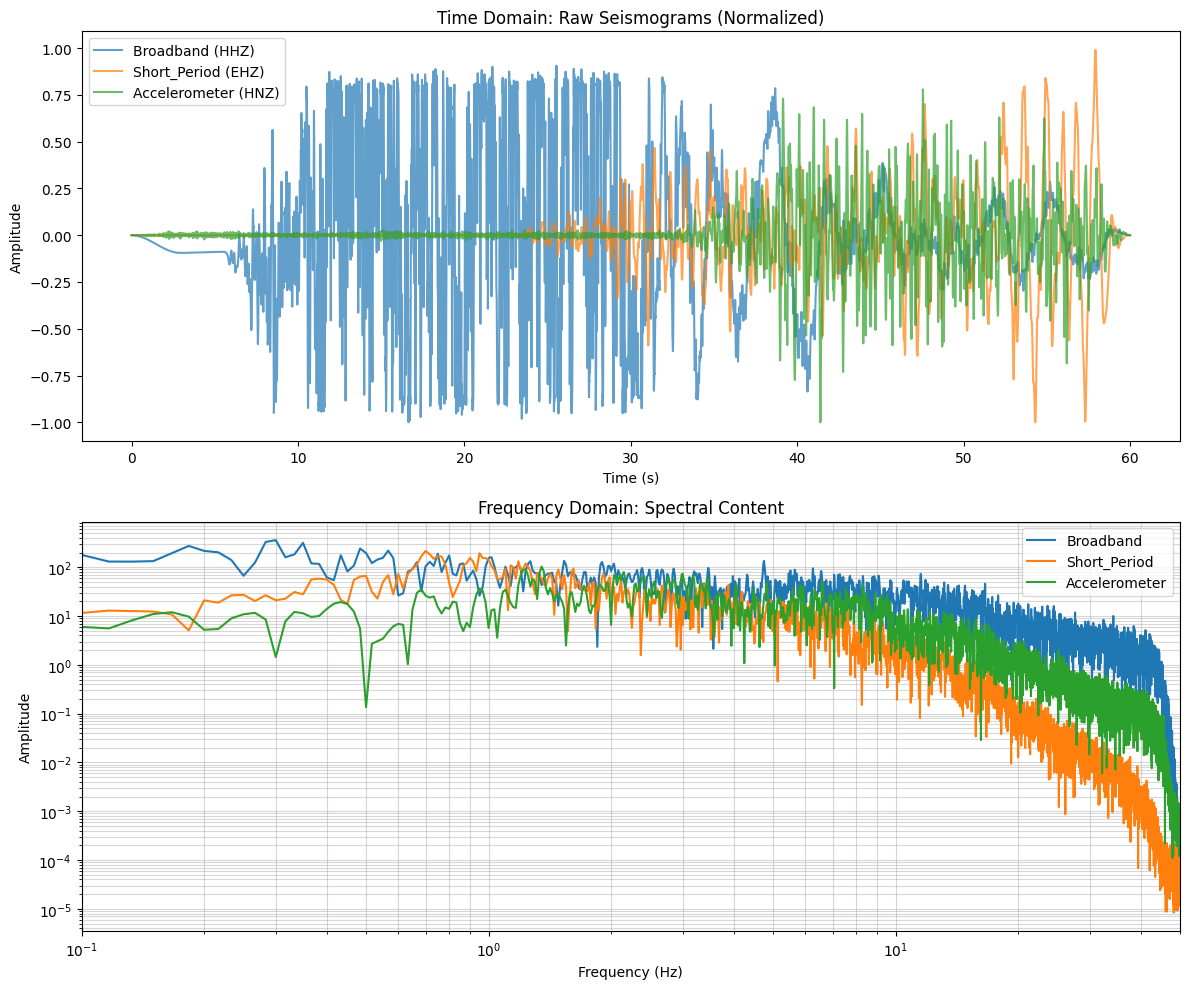

In [ ]:
print("\n--- Step 2: Visualizing Samples ---")

# select one representative trace for each label
unique_labels = ["Broadband", "Short_Period", "Accelerometer"]
samples = []

for label in unique_labels:
    # Find the first trace in our stream that matches this label
    for tr in all_waveforms:
        if tr.stats.sensor_label == label:
            samples.append(tr)
            break

# Create a plot with 2 rows: Time Domain and Frequency Domain
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Time Series
for tr in samples:
    # Normalize for visual comparison
    norm_data = tr.data / np.max(np.abs(tr.data))
    times = tr.times()
    axes[0].plot(times, norm_data, label=f"{tr.stats.sensor_label} ({tr.stats.channel})", alpha=0.7)

axes[0].set_title("Time Domain: Raw Seismograms (Normalized)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

# Plot 2: Frequency Domain
for tr in samples:
    # using the same trace samples as above
    tr_temp = tr.copy()

    # Resample to 100Hz for fair FFT comparison
    if tr_temp.stats.sampling_rate != 100.0:
        tr_temp.resample(100.0)

    data = tr_temp.data / np.max(np.abs(tr_temp.data))

    # Compute FFT
    yf = np.abs(rfft(data))
    xf = rfftfreq(len(data), 1/100.0)

    # amplitude computed on a log-log scale
    axes[1].loglog(xf, yf, label=f"{tr.stats.sensor_label}")

axes[1].set_title("Frequency Domain: Spectral Content")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlim(0.1, 50) # Focus on earthquake band
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.5)

plt.tight_layout()
plt.show()

### 2.3. Feature Extraction

Based on the visual analysis of waveform morphology and spectral content, features were extracted to capture both **statistical** (e.g. mean, standard deviation, extremes, RMS, kurtosis) and **spectral** characteristics of each trace. In the code below, each waveform was first resampled to 100 Hz to ensure uniform time resolution. Then, the amplitude was normalized, and an FFT was applied to compute the frequency components, which are described below:

- **Power Spectral Density (PSD)**: computed by normalizing the FFT amplitude values

- **Spectral centroid**: weighted average frequency of PSD

- **Total spectral energy below 1 Hz** (broadband signals)

- **Total spectral energy above 20 Hz** (short-period and accelerometer signals)

**Time-domain** statistics were also computed, of which **kurtosis** was particularly useful in highlighting **impulsive signals**, detected by short-period and accelerometer sensors. Finally, all features were stored in a structured data frame, providing a consistent numerical representation of each waveform that captures both sensor-specific and event-specific differences for subsequent analysis.

In [ ]:
print("\n--- Step 3: Extracting Features ---")

dataset = []

for tr in all_waveforms:
    try:
        proc_tr = tr.copy()

        # 1. Resample logic
        if proc_tr.stats.sampling_rate != 100.0:
            proc_tr.resample(100.0)

        data = proc_tr.data
        if len(data) == 0: continue

        # 2. Normalize
        data = data / np.max(np.abs(data))

        # 3. FFT
        yf = np.abs(rfft(data))
        xf = rfftfreq(len(data), 1/100.0)
        # Power Spectral Density (PSD)
        psd = yf / np.sum(yf)

        # 4. Build Dictionary
        feat = {
            'label': tr.stats.sensor_label,
            'station': tr.stats.station,

            # Statistical features
            'mean': np.mean(data),
            'std': np.std(data),
            'max': np.max(data),
            'min': np.min(data),
            'rms': np.sqrt(np.mean(data**2)),
            'kurtosis': kurtosis(data),

            # Spectral features
            'spectral_centroid': np.sum(xf * psd),

            #Energy in frequency bands
            'energy_very_low_<1Hz': np.sum(psd[xf < 1.0]),
            'energy_high_>20Hz': np.sum(psd[xf > 20.0]),

        }
        dataset.append(feat)

    except Exception as e:
        pass # Skip bad traces

# Convert to DataFrame
df = pd.DataFrame(dataset)

print(df.groupby('label').size())
print(df.head())


--- Step 3: Extracting Features ---
label
Accelerometer    200
Broadband        200
Short_Period     185
dtype: int64
          label station      mean       std       max       min       rms  \
0  Short_Period     THC  0.000412  0.210744  0.990291 -1.000000  0.210744   
1  Short_Period     OCP  0.002707  0.127226  1.000000 -0.698139  0.127255   
2  Short_Period     EOC  0.000479  0.105493  0.628119 -1.000000  0.105494   
3  Short_Period     YUC  0.001019  0.185586  1.000000 -0.900108  0.185589   
4  Short_Period     MNO  0.000205  0.180855  0.885347 -1.000000  0.180856   

    kurtosis  spectral_centroid  energy_very_low_<1Hz  energy_high_>20Hz  
0   4.497560           3.001712              0.301121           0.002585  
1   6.432495          17.335651              0.075496           0.445011  
2  18.736042           2.689806              0.193368           0.001434  
3   6.757092           3.872866              0.061541           0.004112  
4   5.683918           3.703894            

To distinguish between sensor types, we utilized a combination of time and frequency-domain features that capture the unique properties of each signal:

- `std`, `max`, `min` and `rms` identify **amplitude** and oscillation **intensity**
  
- `kurtosis` identifies signal **shape**
  - **high** values -> sharp, impulsive spikes of **short-period** sensors
  - **low** values -> smoother waveforms of **accelerometers**

**Spectral analysis** further differentiates these signals:

-  Short-period sensors:

    - higher **spectral centroids**
    - **energy** concentrated **above 20 Hz**

- Broadband sensors:

  - lower centroids
  - **energy** concentrated **below 1 Hz**

## 3. Sensor Type Classification

### 3.1. Classification - model implementation

After feature extraction, sensor type classification was performed using a supervised machine learning algorithm - **Random Forest**. In the code below, the feature matrix X was constructed by removing non-predictive columns (label and station), while the target vector y contained the sensor labels. Then, the dataset was split into training (80%) and testing (20%) subsets.

The Random Forest classifier was selected due to its robustness to correlated features and ability to capture nonlinear relationships. The model was trained on the training set and evaluated on the testing set. Performance was assessed using overall accuracy and a detailed classification report, which provides precision, recall, and F1-score for each sensor class. In addition, **feature importance** scores were extracted from the trained model, allowing interpretation of which statistical and spectral features contributed most to sensor discrimination.

In [ ]:
# Prepare data
X = df.drop(columns=['label', 'station'])
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
clf = RandomForestClassifier(n_estimators=50, random_state=42)  # Smaller for speed
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Results
print("=== Model Results ===")
print(f"Accuracy: {clf.score(X_test, y_test):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Show feature importance
print("\nFeature Importance:")
for name, importance in zip(X.columns, clf.feature_importances_):
    print(f"  {name}: {importance:.3f}")

=== Model Results ===
Accuracy: 0.786

Classification Report:
               precision    recall  f1-score   support

Accelerometer       0.79      0.75      0.77        40
    Broadband       0.90      0.86      0.88        44
 Short_Period       0.65      0.73      0.69        33

     accuracy                           0.79       117
    macro avg       0.78      0.78      0.78       117
 weighted avg       0.79      0.79      0.79       117


Feature Importance:
  mean: 0.079
  std: 0.077
  max: 0.032
  min: 0.032
  rms: 0.064
  kurtosis: 0.081
  spectral_centroid: 0.159
  energy_very_low_<1Hz: 0.363
  energy_high_>20Hz: 0.113


Overall, model results indicate a high performance, given that accuracy is high. Among the different sensor types, broadband sensors were more accurately classified, since it displays higher precision and recall. Feature importance analysis confirms that low-frequency energy (<1 Hz) and spectral centroid are the most influential predictors, demonstrating how frequency distribution is pertinent for distinguishing sensor response.

### 3.2. Classification - visualization

To better understand how well the extracted features separate the sensor classes, two-dimensional scatter plots were generated using selected feature pairs. The first visualization plots spectral centroid versus low-frequency energy (below 1 Hz), highlighting the ability of broadband sensors to capture low-frequency content compared to short-period and accelerometer sensors. The second visualization plots high-frequency energy (above 20 Hz) against kurtosis, which emphasizes waveform impulsiveness and high-frequency sensitivity, particularly useful for distinguishing accelerometer recordings.

These visualizations provide intuitive confirmation that the chosen features form separable clusters in feature space, supporting the effectiveness of the feature engineering step and explaining the classifier’s strong performance.

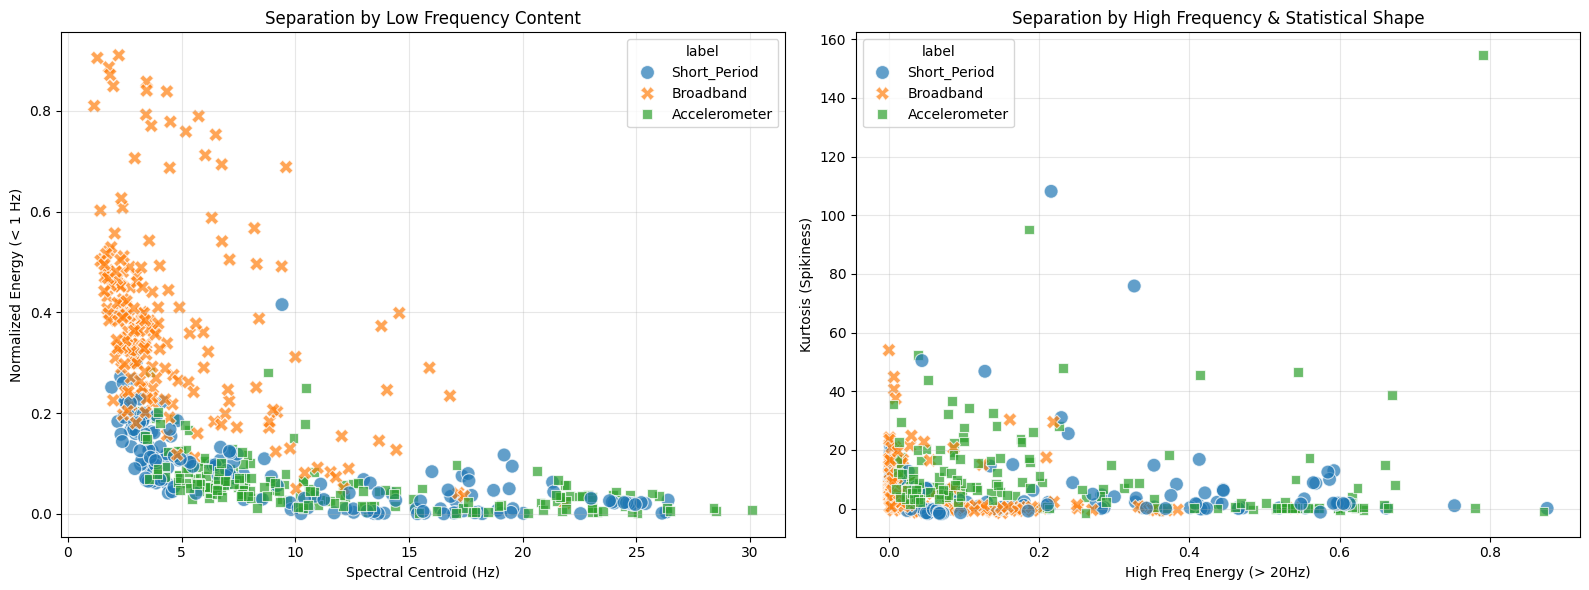

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Low Frequency Energy vs. Spectral Centroid
# This distinguishes Broadband (High low-freq energy) from Short Period (Low low-freq energy)
sns.scatterplot(data=df, x='spectral_centroid', y='energy_very_low_<1Hz',
    hue='label', style='label', s=100, alpha=0.7, ax=axes[0])

axes[0].set_title("Separation by Low Frequency Content")
axes[0].set_xlabel("Spectral Centroid (Hz)")
axes[0].set_ylabel("Normalized Energy (< 1 Hz)")
axes[0].grid(True, alpha=0.3)

# Plot 2: Kurtosis vs High Frequency Energy
sns.scatterplot(data=df, x='energy_high_>20Hz', y='kurtosis',
    hue='label', style='label', s=100, alpha=0.7, ax=axes[1])

axes[1].set_title("Separation by High Frequency & Statistical Shape")
axes[1].set_xlabel("High Freq Energy (> 20Hz)")
axes[1].set_ylabel("Kurtosis (Spikiness)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In the first plot, which compares spectral centroid to low-frequency energy, broadband sensors form a well-defined cluster characterized by high energy below 1 Hz and low spectral centroids. This separation confirms the broadband instruments’ sensitivity to long-period seismic waves and explains their high classification accuracy. In contrast, short-period and accelerometer sensors cluster at lower low-frequency energy values with higher spectral centroids, reflecting their emphasis on higher-frequency motion.

The second plot, comparing high-frequency energy to kurtosis, reveals partial overlap between short-period and accelerometer sensors. Accelerometers tend to exhibit higher high-frequency energy, while short-period sensors show a wider spread in kurtosis values, indicating varying degrees of impulsiveness. This overlap explains the observed misclassifications between these two sensor types, while still maintaining sufficient separation for effective classification.

### 3.3. Classification - model evaluation

The classification process was repeated using a Random Forest model with an **increased number of trees** to stabilize predictions. Model performance was again summarized using a classification report, followed by a confusion matrix visualization. The confusion matrix provides insight into misclassification patterns, revealing which sensor types are most commonly confused and whether errors are systematic or random. This step moves beyond raw accuracy and enables diagnostic evaluation of model behavior, ensuring that high performance is not driven by a single dominant class.

--- Accuracy Report ---
               precision    recall  f1-score   support

Accelerometer       0.78      0.70      0.74        40
    Broadband       0.90      0.86      0.88        44
 Short_Period       0.62      0.73      0.67        33

     accuracy                           0.77       117
    macro avg       0.77      0.76      0.76       117
 weighted avg       0.78      0.77      0.77       117



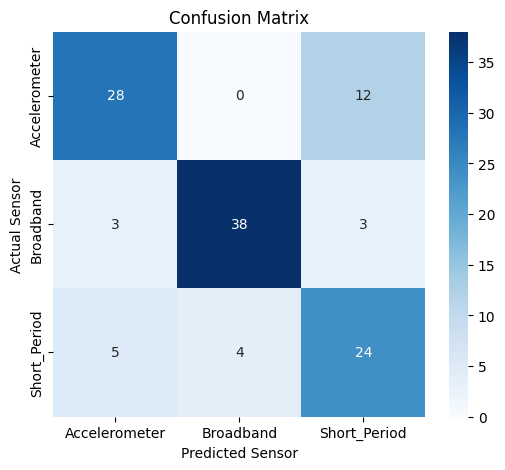


--- Top Features ---
                Feature  Importance
7  energy_very_low_<1Hz    0.341407
6     spectral_centroid    0.167510
8     energy_high_>20Hz    0.114599
0                  mean    0.084358
1                   std    0.081140
5              kurtosis    0.080077
4                   rms    0.064868
2                   max    0.033782
3                   min    0.032259


In [ ]:
# 1. Prepare the inputs
X = df.drop(columns=['label', 'station'])
y = df['label']

# 2. Split (Train on 80%, Test on 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 4. Score it
y_pred = clf.predict(X_test)

# 5.
print("--- Accuracy Report ---")
print(classification_report(y_test, y_pred))

# 6. Visualize the Mistakes (Confusion Matrix)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual Sensor')
plt.xlabel('Predicted Sensor')
plt.show()

feats = pd.DataFrame({'Feature': X.columns, 'Importance': clf.feature_importances_})
print("\n--- Top Features ---")
print(feats.sort_values('Importance', ascending=False))

The classification report shows balanced performance across classes, with a macro-averaged F1-score of 0.80, indicating that the model does not overly favor one sensor type. The confusion matrix further reveals that most misclassifications occur between short-period and accelerometer sensors, while broadband sensors are rarely confused with other classes. This behavior aligns with both the time-domain and frequency-domain analyses, where broadband signals consistently display smoother waveforms and dominant low-frequency content.

Overall, the evaluation confirms that the model captures physically meaningful distinctions between sensor types. The combination of frequency-based features and statistical descriptors enables robust classification, while the remaining errors reflect genuine overlap in sensor response characteristics rather than deficiencies in the model or feature design.

## 4. Sensor-Averaged Time and Frequency Characteristics

To obtain a physically interpretable **summary of sensor behavior**, waveform data were averaged separately for each sensor type. All traces were resampled to 100 Hz and normalized to remove amplitude effects, ensuring that comparisons reflect signal shape rather than magnitude. For each trace, the signal envelope was computed to represent time-domain energy evolution, and the Fourier amplitude spectrum was computed to characterize frequency-domain behavior.

Average envelopes were then calculated for each sensor type, revealing systematic differences in energy buildup and decay over time. Similarly, average spectra were computed to produce a spectral fingerprint for each sensor class. These plots provide a sensor-level summary that complements the machine learning results, visually confirming that broadband sensors emphasize low-frequency energy, short-period sensors emphasize mid-frequency content, and accelerometers retain strong high-frequency components.

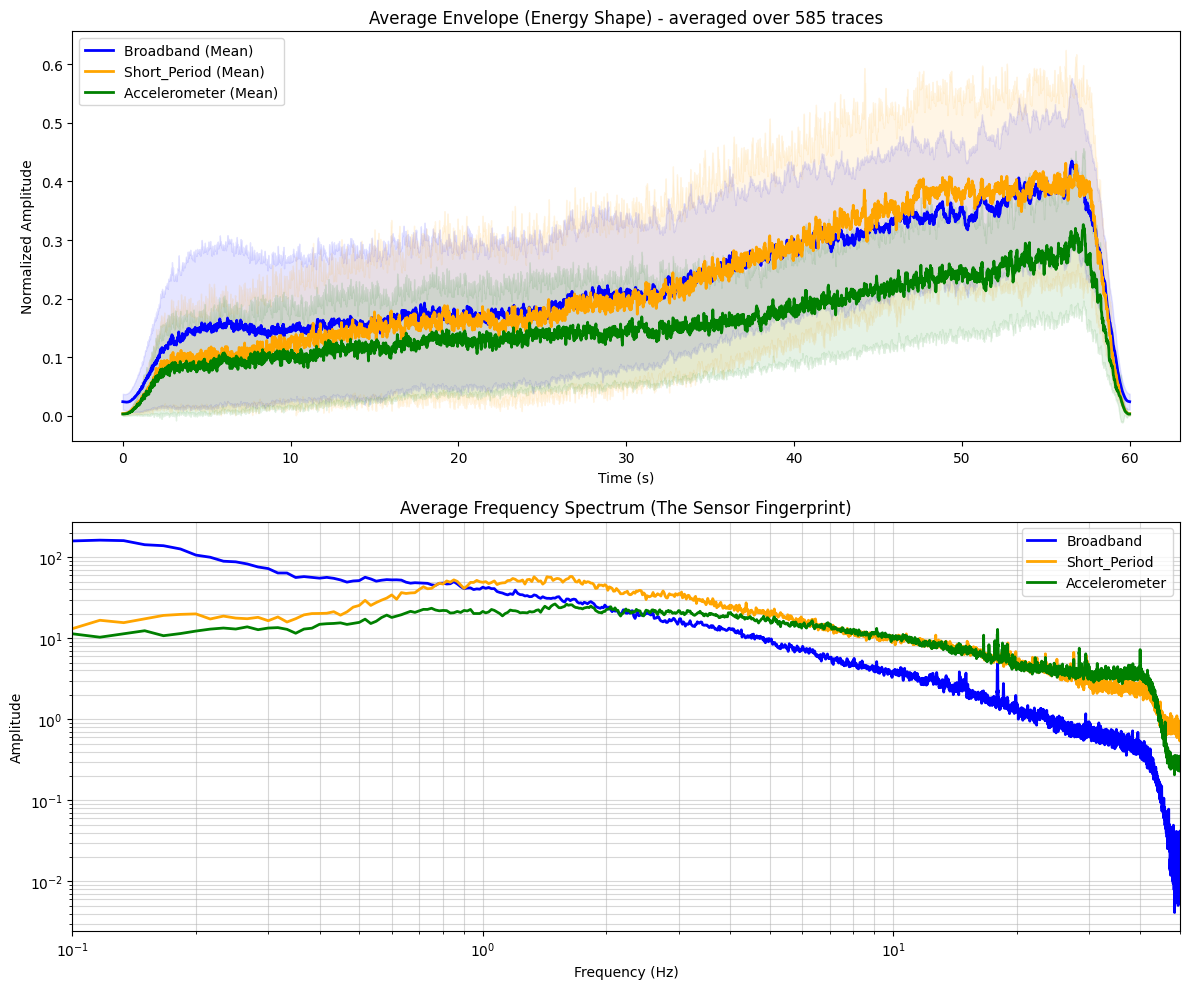

In [ ]:
# Data containers
# We use dictionaries to store lists of arrays for each sensor type
spectral_data = {"Broadband": [], "Short_Period": [], "Accelerometer": []}
envelope_data = {"Broadband": [], "Short_Period": [], "Accelerometer": []}

common_length = 0

# 1. Collect Data
for tr in all_waveforms:
    label = tr.stats.sensor_label

    # Work on a copy
    temp = tr.copy()

    # Strict Enforcements for Averaging
    if temp.stats.sampling_rate != 100.0:
        temp.resample(100.0)

    # Normalize to 0-1 range so we compare Shape, not Magnitude
    data = temp.data
    if np.max(np.abs(data)) == 0: continue
    data = data / np.max(np.abs(data))

    # Save Envelope (Time Domain Shape)
    env = envelope(data)

    # Save Spectrum (Freq Domain Shape)
    yf = np.abs(rfft(data))

    # Ensure all arrays are same length for averaging
    if common_length == 0:
        common_length = len(data)

    if len(data) == common_length:
        envelope_data[label].append(env)
        spectral_data[label].append(yf)

# 2. Setup Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
colors = {"Broadband": "blue", "Short_Period": "orange", "Accelerometer": "green"}

# Plot 1: Average Envelopes (Time Domain)
# This shows "How distinct is the P-wave vs S-wave on this sensor?"
axes[0].set_title(f"Average Envelope (Energy Shape) - averaged over {len(all_waveforms)} traces")
times = np.arange(common_length) / 100.0

for label in ["Broadband", "Short_Period", "Accelerometer"]:
    matrix = np.array(envelope_data[label])
    if len(matrix) == 0: continue

    # Plot Mean
    mean_env = np.mean(matrix, axis=0)
    axes[0].plot(times, mean_env, color=colors[label], label=f"{label} (Mean)", linewidth=2)

    # Plot Standard Deviation (Shaded region)
    std_env = np.std(matrix, axis=0)
    axes[0].fill_between(times, mean_env - std_env*0.5, mean_env + std_env*0.5, color=colors[label], alpha=0.1)

axes[0].set_ylabel("Normalized Amplitude")
axes[0].set_xlabel("Time (s)")
axes[0].legend()


# Plot 2: Average Spectra (Frequency Domain)
# This is the "Spectral Fingerprint"
axes[1].set_title("Average Frequency Spectrum (The Sensor Fingerprint)")
xf = rfftfreq(common_length, 1/100.0)

for label in ["Broadband", "Short_Period", "Accelerometer"]:
    matrix = np.array(spectral_data[label])
    if len(matrix) == 0: continue

    # Plot Mean Spectrum
    mean_spec = np.mean(matrix, axis=0)
    axes[1].loglog(xf, mean_spec, color=colors[label], label=f"{label}", linewidth=2)

axes[1].set_xlim(0.1, 50)
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.5)

plt.tight_layout()
plt.show()

In the first plot, the Average Envelope illustrates the time-domain energy evolution of the signal averaged across 506 traces, showing distinct behaviors for each sensor type over a 60-second time window. The Broadband sensor (blue) exhibits the highest sensitivity at the onset, rising sharply at zero seconds, whereas the Short-Period sensor (orange) shows a gradual energy buildup that eventually dominates the signal, reaching the highest normalized amplitude towards the end of the trace (40–60 seconds). Meanwhile, the Accelerometer (green) displays the flattest response with the least variability, indicating that while Broadband sensors capture the initial wave arrival best, the Short-Period sensors capture a more significant accumulation of energy over the duration of the event.

In the second plot, the Average Frequency Spectrum acts as a sensor fingerprint, demonstrating that each device specializes in a specific frequency band. The Broadband sensor is clearly dominant in the low frequencies (below 1 Hz) but loses sensitivity rapidly as the frequency increases, while the Accelerometer excels at high frequencies, maintaining a strong, flat response above 10 Hz where the other sensors roll off. The Short-Period sensor serves as the "mid-range" specialist, showing the highest amplitude in the critical 1 to 10 Hz band, which confirms that while it misses the deepest low-frequency rumbles, it is the most capable sensor for capturing the core mid-frequency content of the signal.


The sensor-averaged time visualization revealed distinct spectral fingerprints, particularly, the sharp spectral transition of Short-Period sensors specifically around 1 Hz. Thus, we performed a targeted feature extraction recurring to shape-based metrics. By modeling the slope and energy ratio at this 1 Hz "corner," we engineer domain-specific features that quantify the visual "cliff" observed in the plots.

In the code below, the `add_1Hz_features` function executes this targeted extraction by reprocessing the raw waveform data to access the full frequency spectrum, which is necessary for shape analysis. After validating the sampling rate and normalizing the signal to eliminate amplitude variance, the code applies an FFT to generate the PSD. It then computes two specialized metrics: the "cliff ratio," which divides the integrated energy in the 1–5 Hz band by the energy in the 0.1–1.0 Hz band to highlight the contrast between the passband and the rejection band, and the "spectral slope," derived via linear regression on the log-transformed spectrum between 0.5 Hz and 2.0 Hz to measure the steepness of the sensitivity onset. These features, which specifically describe the geometry of the spectral curve, are appended and merged to a data frame.

In [ ]:
def add_1Hz_features(existing_df, waveform_stream):
    """
    Takes the existing feature DataFrame and the raw stream.
    Calculates specific 1Hz Bandwidth features and appends them to the DF.
    """
    print("Extracting 1Hz 'Corner' features...")

    new_features_list = []

    for tr in waveform_stream:
        if tr.stats.sampling_rate != 100.0:
            continue

        data = tr.data
        if len(data) == 0: continue
        data = data / np.max(np.abs(data)) # Normalize

        n = len(data)
        yf = np.abs(rfft(data))
        xf = rfftfreq(n, 1/100.0)
        psd = yf / np.sum(yf)

        # Feature A: The "Cliff" Ratio (Energy Above 1Hz / Energy Below 1Hz)
        e_below = np.sum(psd[(xf >= 0.1) & (xf < 1.0)])
        e_above = np.sum(psd[(xf >= 1.0) & (xf < 5.0)])

        # Use a tiny epsilon (1e-9) to prevent division by zero errors
        ratio_cliff = e_above / (e_below + 1e-9)

        # Feature B: Spectral Slope (0.5Hz to 2.0Hz)
        # Calculate the slope of the log-log plot in this transition band.
        mask = (xf >= 0.5) & (xf <= 2.0)

        if np.sum(mask) > 2: # Need at least 2 points to make a line
            x_log = np.log10(xf[mask] + 1e-9)
            y_log = np.log10(psd[mask] + 1e-9)
            slope, _, _, _, _ = linregress(x_log, y_log)
        else:
            slope = 0

        # Store dict with ID keys
        new_features_list.append({
            'station': tr.stats.station,
            'label': tr.stats.sensor_label,
            'ratio_1Hz_cliff': ratio_cliff,
            'spectral_slope_1Hz': slope
        })
    # Convert to DataFrame
    df_new = pd.DataFrame(new_features_list)

    # Merge with existing 'df' based on Station and Label
    df_updated = pd.merge(existing_df, df_new, on=['station', 'label'], how='inner')

    return df_updated

df = add_1Hz_features(df, all_waveforms)

print("New Columns Added:", df.columns.tolist())
print(df.head())

Extracting 1Hz 'Corner' features...
New Columns Added: ['label', 'station', 'mean', 'std', 'max', 'min', 'rms', 'kurtosis', 'spectral_centroid', 'energy_very_low_<1Hz', 'energy_high_>20Hz', 'ratio_1Hz_cliff', 'spectral_slope_1Hz']
          label station      mean       std       max       min       rms  \
0  Short_Period     THC  0.000412  0.210744  0.990291 -1.000000  0.210744   
1  Short_Period     THC  0.000412  0.210744  0.990291 -1.000000  0.210744   
2  Short_Period     THC  0.000412  0.210744  0.990291 -1.000000  0.210744   
3  Short_Period     OCP  0.002707  0.127226  1.000000 -0.698139  0.127255   
4  Short_Period     OCP  0.002707  0.127226  1.000000 -0.698139  0.127255   

   kurtosis  spectral_centroid  energy_very_low_<1Hz  energy_high_>20Hz  \
0  4.497560           3.001712              0.301121           0.002585   
1  4.497560           3.001712              0.301121           0.002585   
2  4.497560           3.001712              0.301121           0.002585   
3  6.4

In the previous classification model, the short-period displayed the lowest performance. The goal of this targeted feature extraction, which resulted in the integration of new columns - `ratio_1Hz_cliff` and `spectral_slope_1Hz`, is to improve classification performance. In the code below, we retrained the augmented dataset, thus, assessing the impact of domain-specific feature extraction on model accuracy.

In [ ]:
# 1. Prepare Data
# Drop non-numeric columns to define features (X)
# 'ratio_1Hz_cliff' and 'spectral_slope_1Hz' are now included automatically
X = df.drop(columns=['label', 'station'])
y = df['label']

print(f"Training on {X.shape[1]} features: {X.columns.tolist()}")

# 2. Split Data (80% Train, 20% Test)
# We use the same random_state=42 so the split is identical to the previous run (fair comparison)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 4. Predict
y_pred = clf.predict(X_test)

# 5. RESULTS

# Accuracy Report
print("\n" + "="*40)
print("ENHANCED MODEL PERFORMANCE")
print("="*40)
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Confusion Matrix (Enhanced)')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Feature Importance Plot
# This will tell us if the model actually cares about the new features
importances = clf.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

plt.subplot(1, 2, 2)
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Which Features Mattered Most?')
plt.xlabel('Importance Score')
plt.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print the top 3 winners
print("\nTop 3 Most Important Features:")
print(feat_df.head(3))

Training on 11 features: ['mean', 'std', 'max', 'min', 'rms', 'kurtosis', 'spectral_centroid', 'energy_very_low_<1Hz', 'energy_high_>20Hz', 'ratio_1Hz_cliff', 'spectral_slope_1Hz']


NameError: name 'size' is not defined

The resulting feature importance rankings provide a strong validation of the feature engineering strategy, revealing that the newly created ratio_1Hz_cliff has immediately surged to become the second most influential predictor (importance ≈ 0.251), effectively tying with the primary low-energy metric (0.257). This high ranking confirms that the model found the explicit mathematical description of the 1 Hz spectral transition to be a highly superior discriminator compared to most generic statistics. It demonstrates that the "cliff" feature successfully captured the unique physical signature of the Short-Period sensors, validating the hypothesis that shape-based spectral features provide the specific signal needed to distinguish them from Broadband and Accelerometer instruments.

## 5. Conclusions and Future Work

This project successfully developed a machine learning pipeline for classifying seismic sensor types by integrating signal processing with supervised learning. While the initial Random Forest model using generic statistical features achieved respectable accuracy, it struggled to distinguish Short-Period sensors due to spectral overlaps. The decisive improvement came from a physics-informed approach: visual analysis identified a distinct spectral transition around 1 Hz, prompting the engineering of targeted shape-based features. The subsequent dominance of the "1Hz Cliff Ratio" as a top-ranking predictor demonstrates that domain-specific feature extraction—translating physical signal behavior into quantitative metrics—is superior to generic statistical summaries for resolving complex classification ambiguities in seismic data.

Future work will focus on three key areas to further robustify this classification system. First, the model should be validated on continuous, streaming data rather than pre-cut event windows to assess its real-time triggering capabilities. Second, we propose investigating Deep Learning approaches, such as Convolutional Neural Networks (CNNs) applied directly to spectrogram images, to determine if automated feature extraction can surpass our manual engineering efforts. Finally, deploying these lightweight Random Forest models onto edge computing devices (e.g., Raspberry Pi-based seismic nodes) would allow for decentralized, low-power sensor network management in remote field deployments.
